<a href="https://colab.research.google.com/github/JFish72/CSC-349-Machine-Learning-/blob/main/HW3/churn_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Task One and Two:***

In [2]:
import pandas as pd

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
import pandas as pd

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Task Three, Four, Five and Six:**

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import SGDClassifier

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

df = df.drop(["customerID"], axis = 1)

df["TotalCharges"] = df["TotalCharges"].replace(r"^\s*$", np.nan, regex = True)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

X = df.drop("Churn", axis = 1)
y = df["Churn"]

categorical_columns = X.select_dtypes(include=["object"]).columns
numerical_columns = X.select_dtypes(include=["number"]).columns

numerical_pipeline = Pipeline([("imputer", SimpleImputer(strategy = "median")), ("scaler", StandardScaler())]) # or MinMaxScaler

catergorical_pipeline = Pipeline([("imputer", SimpleImputer(strategy = "most_frequent")), ("encoder", OneHotEncoder())])

preprocessor = ColumnTransformer([("numerical", numerical_pipeline, numerical_columns), ("categorical", catergorical_pipeline, categorical_columns)])

pipeline = Pipeline([("preprocessor", preprocessor),
 ("classifier", SGDClassifier(loss = "log_loss",random_state = 42 ))])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42, stratify = y)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

y_prob = pipeline.predict_proba(X_test)

yes_index = list(pipeline.classes_).index("Yes")

churn_probability = y_prob[:, yes_index]

results = pd.DataFrame({"Actual Churn": y_test.values, "Predicted Churn": y_pred, "Churn Probability": churn_probability})

display(results.head())



,Actual Churn,Predicted Churn,Churn Probability
0,No,No,0.041497
1,No,Yes,0.631715
2,No,No,0.041058
3,No,No,0.229850
4,No,No,0.017366


**Task Seven:**

,Actual Churn,Predicted Churn
0,No,No
1,No,Yes
2,No,No
3,No,No
4,No,No


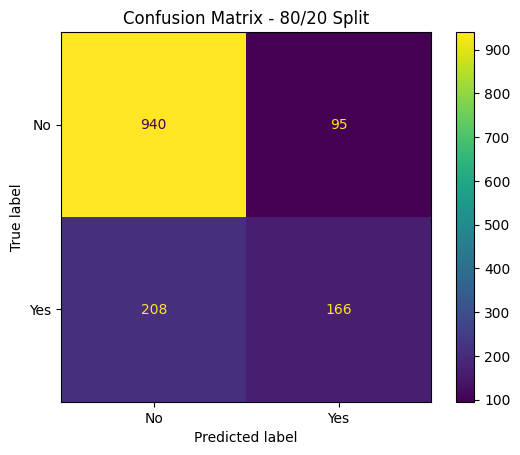

              precision    recall  f1-score   support

          No       0.82      0.91      0.86      1035
         Yes       0.64      0.44      0.52       374

    accuracy                           0.78      1409
   macro avg       0.73      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



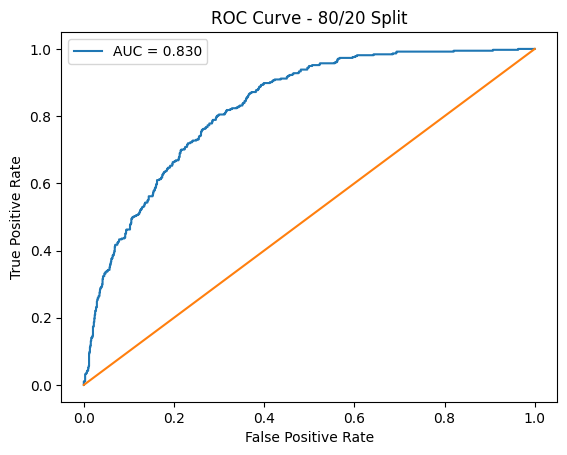

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score, roc_curve)

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

df = df.drop(["customerID"], axis = 1)

df["TotalCharges"] = df["TotalCharges"].replace(r"^\s*$", np.nan, regex = True)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

X = df.drop("Churn", axis = 1)
y = df["Churn"]

categorical_columns = X.select_dtypes(include=["object"]).columns
numerical_columns = X.select_dtypes(include=["number"]).columns

numerical_pipeline = Pipeline([("imputer", SimpleImputer(strategy = "median")), ("scaler", StandardScaler())]) # or MinMaxScaler

catergorical_pipeline = Pipeline([("imputer", SimpleImputer(strategy = "most_frequent")), ("encoder", OneHotEncoder())])

preprocessor = ColumnTransformer([("numerical", numerical_pipeline, numerical_columns), ("categorical", catergorical_pipeline, categorical_columns)])

pipeline = Pipeline([("preprocessor", preprocessor),
 ("classifier", SGDClassifier(loss = "log_loss",random_state = 42 ))])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42, stratify = y)
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state = 42, stratify = y)
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.40, random_state = 42, stratify = y)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

prediction_results = pd.DataFrame({"Actual Churn": y_test.values, "Predicted Churn": y_pred})

display(prediction_results.head())

confusion = confusion_matrix(y_test, y_pred, labels = ["No", "Yes"])

disp = ConfusionMatrixDisplay(confusion_matrix = confusion, display_labels=["No", "Yes"])
disp.plot()

plt.title("Confusion Matrix - 80/20 Split")
#plt.title("Confusion Matrix - 70/30 Split")
#plt.title("Confusion Matrix - 60/40 Split")

plt.show()

print(classification_report(y_test, y_pred))

y_prob = pipeline.predict_proba(X_test)

yes_index = list(pipeline.classes_).index("Yes")

y_test_binary = y_test = (y_test == "Yes").astype(int)

auc_score = roc_auc_score(y_test_binary, y_prob[:, yes_index])

fpr, tpr, thresholds = roc_curve(y_test_binary, y_prob[:, yes_index])

plt.figure()

plt.plot(fpr, tpr, label = f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - 80/20 Split")
#plt.title("ROC Curve - 70/30 Split")
#plt.title("ROC Curve - 60/40 Split
plt.legend()
plt.show()


**Task Eight**

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

feature_importances = pipeline.named_steps["classifier"].coef_[0]

feature_importance_df = pd.DataFrame({"Feature": feature_names, "Importance": feature_importances})

feature_importance_df = feature_importance_df.sort_values(by = "Importance", ascending = False)

display(feature_importance_df.head(10)) # Features that keep customers.
display(feature_importance_df.tail(10)) # Features that push customers away.



,Feature,Importance
16,categorical__InternetService_Fiber optic,1.393056
36,categorical__Contract_Month-to-month,1.105818
40,categorical__PaperlessBilling_Yes,0.896744
32,categorical__StreamingTV_Yes,0.882095
35,categorical__StreamingMovies_Yes,0.858323
27,categorical__TechSupport_No,0.669562
7,categorical__Partner_Yes,0.632036
11,categorical__PhoneService_Yes,0.609266
14,categorical__MultipleLines_Yes,0.601330
21,categorical__OnlineBackup_No,0.594517


,Feature,Importance
25,categorical__DeviceProtection_No internet service,0.062820
39,categorical__PaperlessBilling_No,0.061706
33,categorical__StreamingMovies_No,0.037307
30,categorical__StreamingTV_No,0.013535
12,categorical__MultipleLines_No,0.007936
42,categorical__PaymentMethod_Credit card (automa...,-0.036214
38,categorical__Contract_Two year,-0.458215
15,categorical__InternetService_DSL,-0.497426
2,numerical__MonthlyCharges,-1.171496
1,numerical__tenure,-1.218899
